# Validación estadística de la ingeniería de características

Este notebook aplica una criba estadística y clínica rigurosa sobre las 88 variables generadas en la fase de ingeniería de características. El objetivo es reducir la dimensionalidad eliminando ruido, multicolinealidad y variables sin poder discriminativo, asegurando que el modelo final reciba señales independientes y clínicamente relevantes.

**Requisitos previos:** 
Debe existir el archivo `dataset_features.parquet` en el directorio `data/processed/`. Si no está disponible, es necesario ejecutar previamente el notebook de ingeniería de características.

**Metodología de validación secuencial:**
1. **Filtro de prevalencia (Sparsity Check):** Identificación de variables poco frecuentes y rescate clínico.
2. **Análisis de efecto univariante:** Cálculo de $\eta^2$ para variables continuas y $V$ de Cramér para categóricas frente a la variable objetivo (nivel de triaje).
3. **Análisis de multicolinealidad:** Cálculo de correlaciones de Spearman en dos fases (descarte automático y revisión clínica).
4. **Criba final:** Exportación del conjunto definitivo de características validadas.

## 1. Configuración inicial y carga del espacio de características

In [17]:
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, chi2_contingency

from triaje_ia.data.features import (
    cargar_features,
    FEATURES_CONTINUAS,
    FEATURES_BINARIAS,
    FEATURES_CATEGORICAS,
    TODAS_FEATURES,
    TARGET,
    update_metrics_json,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:.4f}".format)

# Rutas de salida
ARTIFACTS_DIR = Path.cwd().parent.parent / "artifacts"
PROCESSED_DIR = Path.cwd().parent.parent / "data" / "processed"
ARTIFACTS_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

METRICS_FILE = ARTIFACTS_DIR / "feature_metrics.json"

def leer_metricas_05() -> dict:
    if not METRICS_FILE.exists():
        return {}
    with open(METRICS_FILE, encoding="utf-8") as f:
        return json.load(f).get("features_con_metricas", {})


print("Imports OK")
print(f"artifacts: {ARTIFACTS_DIR}")
print(f"processed: {PROCESSED_DIR}")

Imports OK
artifacts: c:\Users\CARLOS\triaje-ia-tfg\artifacts
processed: c:\Users\CARLOS\triaje-ia-tfg\data\processed


In [18]:
df = cargar_features(forzar=False)

print(f"\nDataset: {df.shape[0]:,} filas | {df.shape[1]} columnas")
print(f"Features declaradas: {len(TODAS_FEATURES)}  |  Target: '{TARGET}'")
print()

faltantes = [f for f in TODAS_FEATURES if f not in df.columns]
assert not faltantes, f"Features en triaje_ia.data.features pero no en df: {faltantes}"

_permitidas_extra = {"intime", "subject_id"}
_extras = [
    c for c in df.columns if c not in set(TODAS_FEATURES + [TARGET]) and c not in _permitidas_extra
]
if _extras:
    print(
        "ADVERTENCIA: columnas en df no declaradas como feature/target (ni allowlist): "
        f"{_extras}"
    )

print(f"Integridad OK: {len(TODAS_FEATURES)} features | {len(df):,} filas")

print("\nDistribución de acuity:")
_dist = df[TARGET].value_counts().sort_index()
for acuity, count in _dist.items():
    print(f"  Acuity {acuity}: {count:>7,}  ({count/len(df)*100:.1f}%)")


2026-05-09 18:08:39.844 | WARNING  | triaje_ia.data.features:cargar_features:782 - Cargando desde caché: C:\Users\CARLOS\triaje-ia-tfg\data\processed\dataset_features.parquet. Usa forzar=True si cambiaste el pipeline de features.
2026-05-09 18:08:39.912 | SUCCESS  | triaje_ia.data.features:cargar_features:787 - Cargado: 418,100 filas | 89 columnas



Dataset: 418,100 filas | 89 columnas
Features declaradas: 88  |  Target: 'acuity'

Integridad OK: 88 features | 418,100 filas

Distribución de acuity:
  Acuity 1:  24,019  (5.7%)
  Acuity 2: 139,411  (33.3%)
  Acuity 3: 225,066  (53.8%)
  Acuity 4:  28,504  (6.8%)
  Acuity 5:   1,100  (0.3%)


## 2. Filtro de prevalencia (Sparsity Check)

### 2.1. Detección automática de variables escasas

Se calcula la prevalencia de cada variable binaria. Se establece un umbral de marcado automático para aquellas características presentes en menos del 1% o en más del 99% de los casos. Las variables marcadas no se descartan automáticamente, sino que se someten a una revisión clínica individualizada.

In [19]:
sparsity_rows = []
for col in FEATURES_BINARIAS:
    if col not in df.columns:
        continue
    prev = df[col].mean()
    sparsity_rows.append({
        "feature":     col,
        "prevalencia": round(prev * 100, 2),
        "n_positivos": int(df[col].sum()),
        "sparse":      prev < 0.01 or prev > 0.99,
    })

df_sparsity = (
    pd.DataFrame(sparsity_rows)
    .sort_values("prevalencia")
    .reset_index(drop=True)
)

sparse_features = df_sparsity.loc[df_sparsity["sparse"], "feature"].tolist()

print(f"Features binarias analizadas : {len(df_sparsity)}")
print(f"Features marcadas como sparse: {len(sparse_features)}")
print()
print(df_sparsity.to_string(index=False))

Features binarias analizadas : 71
Features marcadas como sparse: 8

                  feature  prevalencia  n_positivos  sparse
      llegada_helicoptero       0.1300          535    True
       shock_index_severo       0.2200          915    True
           qsofa_positivo       0.2900         1203    True
               news2_alto       0.4100         1717    True
    cc_alergia_anafilaxia       0.6800         2856    True
            o2sat_bajo_92       0.7200         3015    True
              hipotension       0.7600         3160    True
             med_digoxina       0.8100         3378    True
         med_antiaritmico       1.1000         4619   False
          taquipnea_grave       1.1500         4829   False
    identidad_desconocida       1.4800         6177   False
       med_inmunosupresor       1.5700         6568   False
             frecuentador       1.6000         6684   False
                   fiebre       2.2000         9182   False
     cc_hemorragia_activa       

### 2.2. Regla de rescate clínico

Cada variable marcada por baja prevalencia se evalúa clínicamente para determinar si representa un indicador crítico o si constituye ruido estadístico.

Las decisiones posibles son:
- **Mantener:** La variable avanza al siguiente filtro sin modificaciones.
- **Descartar:** La variable se elimina del conjunto definitivo.
- **Integrar en super-flag:** La variable es rara pero clínicamente relevante, por lo que se agrupa junto con otras en una nueva variable compuesta, en lugar de mantenerse de forma individual.

Las variables que poseen un equivalente continuo en el modelo (por ejemplo, `o2sat_bajo_92` frente a `o2sat`) avanzan al siguiente nivel, donde se resolverá la redundancia durante el análisis de multicolinealidad.

In [20]:
# Edita este diccionario si no estas de acuerdo con alguna decision antes de ejecutar
DECISIONES_RESCATE = {
    # feature: ("decision", "motivo")
    "llegada_helicoptero":   ("mantener",           "Predictor fuerte de acuity 1 sin equivalente continuo; 535 casos suficientes"),
    "shock_index_severo":    ("descartar",          "Redundante con sbp+heartrate continuos y shock_index_alto; subset extremo sin valor residual"),
    "qsofa_positivo":        ("mantener",           "Score clínico consolidado para riesgo de sepsis; predictor independiente de alta mortalidad"),
    "news2_alto":            ("mantener",           "Score de alerta temprana validado; señala deterioro inminente sin equivalente simple"),
    "cc_alergia_anafilaxia": ("mantener",           "Anafilaxia es emergencia vital; sin equivalente continuo; 2856 casos suficientes"),
    "o2sat_bajo_92":         ("mantener",           "Tiene equivalente continuo (o2sat); se resuelve en Seccion 3 con decision binaria-vs-continua"),
    "hipotension":           ("mantener",           "Tiene equivalente continuo (sbp); se resuelve en Seccion 3 con decision binaria-vs-continua"),
    "med_digoxina":          ("rescatar_superflag", "Marcador cardiaco de riesgo sin equivalente continuo; se agrega a super-flag"),
}

# Derivar listas de cada decision
features_descartadas_sparsity = [f for f, (d, _) in DECISIONES_RESCATE.items() if d == "descartar"]
features_superflag             = [f for f, (d, _) in DECISIONES_RESCATE.items() if d == "rescatar_superflag"]
features_que_pasan             = [f for f, (d, _) in DECISIONES_RESCATE.items() if d == "mantener"]

# Crear super-flag si hay features para rescatar
if features_superflag:
    df["riesgo_complejidad_extrema"] = df[features_superflag].any(axis=1).astype("int8")
    prev_sf = df["riesgo_complejidad_extrema"].mean() * 100
    
    print(f"Super-flag creado: riesgo_complejidad_extrema")
    print(f"  Compuesto de : {features_superflag}")
    print(f"  Prevalencia  : {prev_sf:.2f}% ({int(df['riesgo_complejidad_extrema'].sum()):,} casos)")
    print()

# Resumen de decisiones
print("Resumen de decisiones de rescate clínico:\n")
for feat, (decision, motivo) in DECISIONES_RESCATE.items():
    print(f"  [{decision.upper():<20}] {feat}")
    print(f"                            {motivo}\n")

print(f"Features descartadas en sparsity : {features_descartadas_sparsity}")
print(f"Features en super-flag           : {features_superflag}")

Super-flag creado: riesgo_complejidad_extrema
  Compuesto de : ['med_digoxina']
  Prevalencia  : 0.81% (3,378 casos)

Resumen de decisiones de rescate clínico:

  [MANTENER            ] llegada_helicoptero
                            Predictor fuerte de acuity 1 sin equivalente continuo; 535 casos suficientes

  [DESCARTAR           ] shock_index_severo
                            Redundante con sbp+heartrate continuos y shock_index_alto; subset extremo sin valor residual

  [MANTENER            ] qsofa_positivo
                            Score clínico consolidado para riesgo de sepsis; predictor independiente de alta mortalidad

  [MANTENER            ] news2_alto
                            Score de alerta temprana validado; señala deterioro inminente sin equivalente simple

  [MANTENER            ] cc_alergia_anafilaxia
                            Anafilaxia es emergencia vital; sin equivalente continuo; 2856 casos suficientes

  [MANTENER            ] o2sat_bajo_92
               

**Resultado de la evaluación de prevalencia:**
- Variables descartadas: 1 (`shock_index_severo`).
- Variables integradas en super-flags: 1 (`med_digoxina` se integra en `riesgo_complejidad_extrema`).
- Variables que avanzan al siguiente filtro: 6 (`llegada_helicoptero`, `qsofa_positivo`, `news2_alto`, `cc_alergia_anafilaxia`, `o2sat_bajo_92`, `hipotension`; las dos últimas con equivalente continuo se resuelven en la sección 3).

## 3. Análisis de efecto univariante frente a la variable objetivo

### 3.1. Variables continuas: Kruskal-Wallis y tamaño del efecto ($\eta^2$)

Dado el elevado volumen de datos ($n$ = tamaño del dataset cargado en la celda de carga (ver `len(df)` al ejecutar)), el valor $p$ de las pruebas de hipótesis tiende a cero para cualquier variable con varianza no nula. Por ello, la decisión de mantener o descartar una variable se basa en el tamaño del efecto, medido mediante el estadístico $\eta^2$:

- $\eta^2 < 0.01$: Efecto despreciable. Candidata a ser descartada.
- $0.01 \le \eta^2 \le 0.03$: Efecto pequeño. Requiere revisión clínica manual.
- $\eta^2 > 0.03$: Efecto moderado o grande. Se mantiene en el modelo.

In [21]:
k_grupos = df[TARGET].nunique()   # 5
n_total  = len(df)                # n dinámico: usar len(df) al ejecutar esta celda

kw_rows = []
for col in FEATURES_CONTINUAS:
    if col not in df.columns:
        continue
    groups = [
        df.loc[df[TARGET] == g, col].dropna().values
        for g in sorted(df[TARGET].unique())
    ]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        continue
    H, p = kruskal(*groups)
    eta2 = max(0.0, (H - k_grupos + 1) / (n_total - k_grupos))
    update_metrics_json(col, H=round(H, 4), eta2=round(eta2, 5))
    decision = (
        "descartar" if eta2 < 0.01
        else ("revisar"   if eta2 < 0.03
        else "mantener")
    )
    kw_rows.append({
        "feature":  col,
        "H":        round(H, 1),
        "p":        round(p, 6),
        "eta2":     round(eta2, 5),
        "decision": decision,
    })

df_kw = (
    pd.DataFrame(kw_rows)
    .sort_values("eta2", ascending=False)
    .reset_index(drop=True)
)

print("Kruskal-Wallis + eta2  |  Features continuas  (orden descendente por efecto)")
print()
print(df_kw.to_string(index=False))

df_kw.to_csv(ARTIFACTS_DIR / "kw_continuas.csv", index=False)
print(f"\nExportado: {ARTIFACTS_DIR / 'kw_continuas.csv'}")

Kruskal-Wallis + eta2  |  Features continuas  (orden descendente por efecto)

                 feature          H      p   eta2  decision
                     age 24502.7000 0.0000 0.0586  mantener
                   qsofa 18074.6000 0.0000 0.0432  mantener
                    pain 18059.6000 0.0000 0.0432  mantener
          n_medicamentos 16662.5000 0.0000 0.0398  mantener
                   news2 11498.6000 0.0000 0.0275   revisar
      n_vitales_anomalos 11065.1000 0.0000 0.0265   revisar
                   o2sat  9936.6000 0.0000 0.0238   revisar
                resprate  7054.8000 0.0000 0.0169   revisar
               heartrate  3533.9000 0.0000 0.0084 descartar
          pulse_pressure  1374.0000 0.0000 0.0033 descartar
                     dbp  1223.4000 0.0000 0.0029 descartar
                     sbp  1037.1000 0.0000 0.0025 descartar
      visitas_ultimo_año  1035.5000 0.0000 0.0025 descartar
       n_visitas_previas   999.8000 0.0000 0.0024 descartar
      visitas_ultimo_m

### 3.2. Decisiones sobre variables continuas

#### Variables continuas retenidas

**Scores clínicos compuestos:**
- **qsofa** ($\eta^2 = 0.0432$): Se mantiene. Presenta un tamaño de efecto muy relevante en el conjunto. Clínicamente, agrupa hipotensión, taquipnea y alteración mental en un índice validado para predecir mortalidad, lo cual correlaciona fuertemente con la prioridad de triaje.
- **news2** ($\eta^2 = 0.0275$): Se mantiene. Su inclusión acelera la convergencia de modelos basados en árboles de decisión al aportar interacciones fisiológicas no lineales ya precalculadas.

**Demografía y complejidad basal:**
- **age** ($\eta^2 = 0.0586$): Se mantiene. La edad avanzada altera la presentación de enfermedades y actúa como predictor independiente de gravedad.
- **n_medicamentos** ($\eta^2 = 0.0398$): Se mantiene. Funciona como un indicador robusto de la carga de comorbilidad del paciente; una mayor polifarmacia refleja mayor fragilidad basal.

**Criterios directos de triaje:**
- **pain** ($\eta^2 = 0.0432$): Se mantiene. En los sistemas de triaje estructurados, el dolor severo obliga a asignar niveles de alta urgencia, justificando su fuerte asociación estadística.

**Constantes vitales y fisiología:**
- **n_vitales_anomalos** ($\eta^2 = 0.0265$): Se mantiene. Proporciona una heurística general sobre la inestabilidad del paciente, complementaria a los scores ponderados.
- **o2sat** ($\eta^2 = 0.0238$): Se mantiene. La hipoxia es una manifestación crítica de deterioro clínico.
- **resprate** ($\eta^2 = 0.0169$): Se mantiene. La taquipnea es frecuentemente el marcador más temprano de estrés sistémico.
- **sbp** (Excepción clínica): Se mantiene pese a su bajo $\eta^2$ ($0.0025$). La prueba de Kruskal-Wallis no captura bien relaciones en forma de U. Conservar la presión sistólica de forma continua es fundamental para que los modelos arbóreos identifiquen crisis hipertensivas, las cuales no están penalizadas en el índice qSOFA.

#### Variables continuas descartadas

- **heartrate** ($\eta^2 = 0.0084$): Se descarta. Su capacidad predictiva queda absorbida por la variable compuesta `news2`.
- **pulse_pressure** ($\eta^2 = 0.0033$): Se descarta. Es una derivación lineal altamente colineal que no aporta información adicional a la presión sistólica.
- **dbp** ($\eta^2 = 0.0029$): Se descarta. En contextos de urgencia, la presión diastólica rara vez condiciona el nivel de triaje de forma independiente.
- **Métricas de frecuentación hospitalaria** (`visitas_ultimo_mes`, `visitas_ultimo_año`, `n_visitas_previas`, `dias_desde_ultima_visita`): Se descartan. Presentan tamaños de efecto univariante extremadamente débiles. El concepto clínico subyacente se modela con menor ruido mediante variables binarias específicas como el estado de frecuentador o la primera visita.

### 3.3. Variables binarias y categóricas: $\chi^2$ y $V$ de Cramér

Para las variables categóricas, el criterio de decisión se fundamenta en el estadístico $V$ de Cramér, que cuantifica el tamaño del efecto:

- $V < 0.07$: Efecto despreciable. Candidata a descarte.
- $0.07 \le V \le 0.10$: Efecto pequeño. Requiere revisión manual y justificación clínica.
- $V > 0.10$: Efecto moderado o grande. Se mantiene.

Este análisis excluye las variables previamente descartadas por baja prevalencia o aquellas absorbidas en super-flags compuestos.

In [22]:
# Decisiones sobre continuas (resultado Seccion 3a)
CONTINUAS_MANTENER = [
    "qsofa", "news2", "age", "pain", "n_medicamentos",
    "n_vitales_anomalos", "o2sat", "resprate", "sbp",
]
CONTINUAS_DESCARTAR = [
    "heartrate", "pulse_pressure", "dbp",
    "visitas_ultimo_mes", "visitas_ultimo_año",
    "n_visitas_previas", "dias_desde_ultima_visita",
]

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2_val, p, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    phi2 = chi2_val / n
    r, k = ct.shape
    phi2corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    V = np.sqrt(phi2corr / denom) if denom > 0 else 0.0
    return round(chi2_val, 1), round(p, 6), round(V, 5)

# Features activas para este analisis
features_binarias_activas = [
    f for f in FEATURES_BINARIAS
    if f not in features_descartadas_sparsity
    and f not in features_superflag
]
if "riesgo_complejidad_extrema" in df.columns:
    features_binarias_activas.append("riesgo_complejidad_extrema")

chi2_rows = []
for col in features_binarias_activas + FEATURES_CATEGORICAS:
    if col not in df.columns:
        continue
    chi2_val, p, V = cramers_v(df[col], df[TARGET])
    update_metrics_json(col, V_cramer=round(V, 5))
    decision = (
        "descartar" if V < 0.07
        else ("revisar"   if V < 0.10
        else "mantener")
    )
    chi2_rows.append({
        "feature":  col,
        "chi2":     chi2_val,
        "p":        p,
        "V_cramer": V,
        "decision": decision,
    })

df_chi2 = (
    pd.DataFrame(chi2_rows)
    .sort_values("V_cramer", ascending=False)
    .reset_index(drop=True)
)

print("Chi2 + V de Cramer  |  Features binarias y categoricas  (orden descendente por efecto)")
print()
print(df_chi2.to_string(index=False))

df_chi2.to_csv(ARTIFACTS_DIR / "chi2_binarias.csv", index=False)
print(f"\nExportado: {ARTIFACTS_DIR / 'chi2_binarias.csv'}")

Chi2 + V de Cramer  |  Features binarias y categoricas  (orden descendente por efecto)

                   feature       chi2      p  V_cramer  decision
       temperature_missing 70959.4000 0.0000    0.4120  mantener
             o2sat_missing 61864.8000 0.0000    0.3846  mantener
              pain_missing 43536.9000 0.0000    0.3227  mantener
               hipotension 31105.0000 0.0000    0.2727  mantener
          llegada_autonoma 31021.1000 0.0000    0.2724  mantener
        llegada_ambulancia 27297.0000 0.0000    0.2555  mantener
          vitales_criticos 18407.3000 0.0000    0.2098  mantener
          shock_index_alto 18218.6000 0.0000    0.2087  mantener
               cc_gi_agudo 18161.4000 0.0000    0.2084  mantener
                   anciano 16612.5000 0.0000    0.1993  mantener
              cc_neuro_ams 15744.8000 0.0000    0.1940  mantener
              polifarmacia 14685.1000 0.0000    0.1874  mantener
     cc_derivacion_urgente 14482.4000 0.0000    0.1861  mantener
  

In [23]:
# --- Overrides clínicos auditables (guía §7) ---
metricas_05 = leer_metricas_05()

# cc_alergia_anafilaxia: emergencia rara pero crítica — exigimos señal mínima estable
assert "cc_alergia_anafilaxia" in df.columns
_prev_cc_aa = float(df["cc_alergia_anafilaxia"].mean())
assert _prev_cc_aa >= 0.0005, f"cc_alergia_anafilaxia demasiado rara para override: prev={_prev_cc_aa:.6f}"

_V_cc_aa = float((metricas_05.get("cc_alergia_anafilaxia") or {}).get("V_cramer") or 0.0)
assert _V_cc_aa >= 0.03, f"cc_alergia_anafilaxia sin señal mínima en métricas persistidas: V={_V_cc_aa}"

print("Overrides clínicos (efecto): OK")


Overrides clínicos (efecto): OK


### 3.4. Decisiones sobre variables binarias y categóricas

**Observaciones preliminares:**
Destaca que las variables que indican ausencia de registro (missingness) de ciertas constantes vitales (`temperature_missing`, `o2sat_missing`, `pain_missing`) muestran los valores de $V$ de Cramér más altos ($0.32 - 0.41$). Esto respalda la hipótesis de que la omisión de un dato clínico en el triaje no es aleatoria, sino informativa sobre la gravedad extrema (paciente que ingresa directamente a reanimación) o la levedad del caso.

Además, ciertas variables binarias que marcan umbrales clínicos (como `o2sat_bajo_92`) presentan tamaños de efecto mayores que sus contrapartidas continuas. Esto indica que el umbral clínico recoge un salto cualitativo real en el riesgo.

#### Variables binarias retenidas

**Indicadores de ausencia de registro (Missingness NMAR):**
- **temperature_missing**, **o2sat_missing**, **pain_missing** ($V \ge 0.32$): Se mantienen. La ausencia de estos registros es en sí misma un marcador potente del nivel de urgencia. Además, en el caso del dolor, actúa como indicador indirecto de alteración del nivel de consciencia.

**Scores y umbrales clínicos fuertes ($V > 0.10$):**
- **qsofa_positivo**, **news2_alto**, **vitales_criticos**, **anciano**, **zona_verde**, **o2sat_bajo_92**, **anciano_mayor**, **taquipnea_grave**, **polifarmacia**, **hiperpolifarmacia**: Se mantienen de forma provisional. Presentan un tamaño de efecto relevante, pero se someterán al análisis de multicolinealidad para evitar redundancias con sus equivalentes continuos.
- **shock_index_alto** ($V = 0.2087$): Se mantiene. Captura una relación hemodinámica no lineal que las constantes vitales aisladas no pueden reproducir.
- **shock_oculto_anciano** ($V = 0.1477$): Se mantiene. Representa una interacción clínica específica no abarcada por sus componentes individuales.
- **sin_medicacion** ($V = 0.1533$): Se mantiene. Presenta un patrón en U que permite diferenciar perfiles de pacientes de forma más clara que la variable continua de número de medicamentos.

**Logística y motivo de consulta principal:**
- **llegada_autonoma**, **llegada_ambulancia**, **llegada_desconocida** ($V \ge 0.12$): Se mantienen. El modo de llegada actúa como una señal de pre-triaje fundamental.
- Variables de motivo de consulta (como **cc_gi_agudo**, **cc_neuro_ams**, entre otros): Se mantienen por representar síndromes clínicos con alta capacidad discriminativa.

**Medicación e historial clínico ($V \ge 0.07$):**
- Se retienen variables asociadas a tratamientos farmacológicos de riesgo (ej. betabloqueantes, anticoagulantes, riesgo de sangrado) e historiales clínicos relevantes como el **hx_cardiaco** ($V = 0.0771$), al presentar señales estadísticas sólidas que elevan el riesgo de descompensación.

**Excepciones justificadas:**
- **cc_alergia_anafilaxia** ($V = 0.0597$): Se mantiene excepcionalmente. Su baja prevalencia y concentración en niveles de alta urgencia hacen que el estadístico infravalore su importancia real.

#### Variables binarias descartadas

- **hipotension** ($V = 0.2727$): Se descarta directamente. A pesar de su elevado efecto, la información que aporta será inferida automáticamente por el modelo a partir de la presión sistólica continua, evitando redundancias.
- **fiebre**, **hipertension_severa**, **riesgo_depresion_resp**: Se descartan. Sus señales clínicas ya se encuentran capturadas por otras variables compuestas o por variables de falta de registro de mayor impacto.
- **riesgo_complejidad_extrema** ($V = 0.0483$): Se descarta al no alcanzar el umbral estadístico requerido.
- **Historial clínico y motivos de consulta con efecto débil:** Se eliminan antecedentes como el digestivo, respiratorio o psiquiátrico, así como motivos de consulta con $V < 0.07$, ya que no discriminan de forma independiente el nivel de urgencia actual.
- **Variables demográficas y de frecuentación** (`frecuentador`, `primera_visita`, `gender`): Se descartan debido a su escasa capacidad predictiva univariante y para mantener la equidad algorítmica.

**Resumen para el análisis de multicolinealidad:**
Variables como `qsofa_positivo`, `news2_alto` y `anciano`, entre otras, avanzan a la fase de correlación, donde se decidirá su permanencia definitiva frente a sus variables continuas correspondientes.

## 4. Análisis de multicolinealidad (Correlación de Spearman)

En esta fase se evalúa la correlación de Spearman entre las características que superaron los filtros previos. El análisis consta de dos niveles:

1. **Revisión automática ($|
ho| > 0.85$):** Descarte directo de la variable redundante. Se prioriza mantener las representaciones continuas sobre las binarias discretizadas artificialmente.
2. **Revisión manual experta ($0.70 < |
ho| \le 0.85$):** Se evalúa si las variables correlacionadas representan un mismo fenómeno clínico o si, por el contrario, aportan matices complementarios de deterioro.

In [24]:
# Features que han superado los filtros de Sparsity (S2) y Efecto (S3)
CONTINUAS_POST_S3 = [
    "qsofa", "news2", "age", "pain", "n_medicamentos",
    "n_vitales_anomalos", "o2sat", "resprate", "sbp",
]

BINARIAS_DESCARTADAS_S3 = [
    # binaria-vs-continua descartadas en S3
    "hipotension", "fiebre", "hipertension_severa", "riesgo_depresion_resp",
    # super-flag sin señal
    "riesgo_complejidad_extrema",
    # demograficas/equidad
    "gender",
    # historial CCS sin señal
    "hx_digestivo", "hx_trauma_muscular", "hx_metabolico_renal",
    "hx_psiquiatrico", "hx_abuso_sustancias", "hx_infeccioso",
    "hx_respiratorio", "hx_neuro",
    # chief complaint sin señal
    "cc_infeccioso", "cc_hemorragia_activa", "cc_cefalea", "cc_intoxicacion",
    # medicacion sin señal
    "med_corticoide_sistemico", "med_respiratorio_inhalado", "med_antiaritmico",
    "med_antidiabetico_oral", "med_inmunosupresor", "med_diuretico_tiazida",
    # frecuentacion sin señal
    "primera_visita", "frecuentador",
]

# Binarias que pasan a Spearman
binarias_post_s3 = [
    f for f in FEATURES_BINARIAS
    if f not in features_descartadas_sparsity   # S2: shock_index_severo
    and f not in features_superflag             # S2: med_digoxina
    and f not in BINARIAS_DESCARTADAS_S3
]
# override clinico que paso aunque V < 0.07
if "cc_alergia_anafilaxia" not in binarias_post_s3:
    binarias_post_s3.append("cc_alergia_anafilaxia")

FEATURES_POST_EFECTO = CONTINUAS_POST_S3 + binarias_post_s3

print(f"Features entrando a Spearman: {len(FEATURES_POST_EFECTO)}")
print(f"  Continuas : {len(CONTINUAS_POST_S3)}")
print(f"  Binarias  : {len(binarias_post_s3)}")
print()

# Matriz de correlacion de Spearman
corr = df[FEATURES_POST_EFECTO].corr(method="spearman")

# Extraer pares con |rho| > 0.70
pares = []
cols = corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        rho = corr.iloc[i, j]
        if abs(rho) > 0.70:
            pares.append({
                "feature_a": cols[i],
                "feature_b": cols[j],
                "rho":       round(rho, 3),
                "capa":      "AUTO  (>0.85)" if abs(rho) > 0.85 else "MANUAL (0.70-0.85)",
            })

df_pares = (
    pd.DataFrame(pares)
    .sort_values("rho", key=abs, ascending=False)
    .reset_index(drop=True)
)

print(f"Pares con |rho| > 0.70: {len(df_pares)}")
print(f"  Capa automatica (>0.85)   : {(df_pares['capa'].str.startswith('AUTO')).sum()}")
print(f"  Capa manual (0.70-0.85)   : {(df_pares['capa'].str.startswith('MANUAL')).sum()}")
print()
print(df_pares.to_string(index=False))

df_pares.to_csv(ARTIFACTS_DIR / "spearman_pares.csv", index=False)
print(f"\nExportado: {ARTIFACTS_DIR / 'spearman_pares.csv'}")

Features entrando a Spearman: 54
  Continuas : 9
  Binarias  : 45

Pares con |rho| > 0.70: 8
  Capa automatica (>0.85)   : 4
  Capa manual (0.70-0.85)   : 4

         feature_a            feature_b     rho               capa
  llegada_autonoma   llegada_ambulancia -0.9270      AUTO  (>0.85)
med_benzodiacepina alto_riesgo_delirium  0.8820      AUTO  (>0.85)
    n_medicamentos         polifarmacia  0.8740      AUTO  (>0.85)
med_anticoagulante alto_riesgo_sangrado  0.8570      AUTO  (>0.85)
               age              anciano  0.8030 MANUAL (0.70-0.85)
    n_medicamentos       sin_medicacion -0.7770 MANUAL (0.70-0.85)
    n_medicamentos    hiperpolifarmacia  0.7720 MANUAL (0.70-0.85)
  shock_index_alto     vitales_criticos  0.7610 MANUAL (0.70-0.85)

Exportado: c:\Users\CARLOS\triaje-ia-tfg\artifacts\spearman_pares.csv


### 4.1. Decisiones derivadas del análisis de multicolinealidad

**Descartes automáticos ($|
ho| > 0.85$):**
- **llegada_autonoma** ($
ho = -0.927$ con `llegada_ambulancia`): Se descarta por redundancia lógica. La forma de llegada opuesta se infiere indirectamente.
- **med_anticoagulante** ($
ho = 0.857$ con `alto_riesgo_sangrado`): Se descarta porque su información ya está contenida en la variable compuesta de riesgo de sangrado, lo que previene la fragmentación en la interpretabilidad posterior.
- **polifarmacia** ($
ho = 0.874$ con `n_medicamentos`): Se descarta. El modelo extraerá directamente los umbrales relevantes de la variable continua subyacente.
- **med_benzodiacepina** ($
ho = 0.882$ con `alto_riesgo_delirium`): Se descarta al estar subsumida en el indicador de riesgo de delirium.

**Revisión manual ($0.70 < |
ho| \le 0.85$):**
- **anciano** ($
ho = 0.803$ con `age`): Se descarta. Representa exactamente el mismo fenómeno que la edad continua, la cual proporciona mayor resolución.
- **sin_medicacion** ($
ho = -0.777$ con `n_medicamentos`): Se mantienen ambas. El estado de no tomar ninguna medicación aporta información predictiva que la variable continua no separa correctamente en sus extremos.
- **hiperpolifarmacia** ($
ho = 0.772$ con `n_medicamentos`): Se descarta, siguiendo el mismo razonamiento aplicado a la variable de polifarmacia.
- **shock_index_alto** ($
ho = 0.761$ con `vitales_criticos`): Se mantienen ambas. Mientras el índice de shock refleja una relación hemodinámica específica, el conteo de vitales críticos mide la amplitud general del deterioro, aportando señales complementarias.

In [25]:
BINARIAS_DESCARTADAS_SPEARMAN = [
    "llegada_autonoma",    # rho=-0.927 con llegada_ambulancia; mismo fenomeno
    "med_anticoagulante",  # rho=0.857 con alto_riesgo_sangrado; absorbido por super-flag
    "polifarmacia",        # rho=0.874 con n_medicamentos; umbral binario redundante
    "med_benzodiacepina",  # rho=0.882 con alto_riesgo_delirium; absorbido por super-flag
    "anciano",             # rho=0.803 con age; umbral binario redundante
    "hiperpolifarmacia",   # rho=0.772 con n_medicamentos; umbral binario redundante
]

FEATURES_SELECCIONADAS = [
    f for f in FEATURES_POST_EFECTO
    if f not in BINARIAS_DESCARTADAS_SPEARMAN
]

print(f"Features originales (88)      : {len(TODAS_FEATURES)}")
print(f"Features seleccionadas        : {len(FEATURES_SELECCIONADAS)}")
print(f"Reduccion total               : {len(TODAS_FEATURES) - len(FEATURES_SELECCIONADAS)} features eliminadas")
print()
print("Set final — FEATURES_SELECCIONADAS:")
print()

continuas_final = [f for f in FEATURES_SELECCIONADAS if f in CONTINUAS_POST_S3]
binarias_final  = [f for f in FEATURES_SELECCIONADAS if f not in CONTINUAS_POST_S3]

print(f"  Continuas ({len(continuas_final)}):")
for f in continuas_final:
    print(f"    {f}")
print()
print(f"  Binarias ({len(binarias_final)}):")
for f in binarias_final:
    print(f"    {f}")

Features originales (88)      : 88
Features seleccionadas        : 48
Reduccion total               : 40 features eliminadas

Set final — FEATURES_SELECCIONADAS:

  Continuas (9):
    qsofa
    news2
    age
    pain
    n_medicamentos
    n_vitales_anomalos
    o2sat
    resprate
    sbp

  Binarias (39):
    temperature_missing
    o2sat_missing
    pain_missing
    o2sat_bajo_92
    taquipnea_grave
    qsofa_positivo
    news2_alto
    shock_index_alto
    shock_oculto_anciano
    vitales_criticos
    sirs_positivo
    zona_verde
    anciano_mayor
    identidad_desconocida
    llegada_ambulancia
    llegada_helicoptero
    llegada_desconocida
    med_antiagregante
    med_insulina
    med_opiaceo
    med_betabloqueante
    med_ace_ara2
    med_diuretico_asa
    med_antipsicótico
    med_ssri_snri
    med_anticonvulsivante
    alto_riesgo_sangrado
    alto_riesgo_delirium
    sin_medicacion
    cc_dolor_toracico
    cc_disnea
    cc_gi_agudo
    cc_neuro_ams
    cc_trauma
    cc_psiq

### 4.2. Validación adicional mediante correlación parcial

Algunas variables binarias sobrevivieron al filtro principal porque su correlación global con la variable continua generadora fue menor a 0.70. Para estas variables se aplica una prueba de **correlación parcial de Spearman**, la cual mide el grado de asociación residual entre la variable binaria y la variable objetivo, controlando el efecto de la variable continua base.

In [26]:
from scipy.stats import spearmanr

PARES_BVC = [
    ("qsofa_positivo", "qsofa"),
    ("news2_alto",     "news2"),
    ("o2sat_bajo_92",  "o2sat"),
    ("taquipnea_grave","resprate"),
    ("anciano_mayor",  "age"),
]

print("Correlacion parcial de Spearman: rho(binaria, acuity | continuo)")
print("Umbral de decision: |rho_parcial| < 0.05 -> descartar binaria")
print()
print(f"{'binaria':<20} {'continuo':<12} {'rho(B,C)':>9} {'rho(B,Y)':>9} {'rho(C,Y)':>9} {'rho_parcial':>12} {'decision'}")
print("-" * 90)

bvc_descartar = []

for binaria, continuo in PARES_BVC:
    sub = df[[binaria, continuo, TARGET]].dropna()
    
    rho_BC = spearmanr(sub[binaria], sub[continuo]).statistic
    rho_BY = spearmanr(sub[binaria], sub[TARGET]).statistic
    rho_CY = spearmanr(sub[continuo], sub[TARGET]).statistic
    
    num = rho_BY - rho_BC * rho_CY
    den = np.sqrt(max(0, (1 - rho_BC**2) * (1 - rho_CY**2)))
    rho_parcial = round(num / den, 4) if den > 1e-9 else 0.0
    
    decision = "DESCARTAR" if abs(rho_parcial) < 0.05 else "MANTENER"
    if decision == "DESCARTAR":
        bvc_descartar.append(binaria)
    
    print(f"  {binaria:<20} {continuo:<12} {rho_BC:>9.3f} {rho_BY:>9.3f} {rho_CY:>9.3f} {rho_parcial:>12.4f}   {decision}")

print()
print(f"Binarias a descartar por rho_parcial < 0.05: {bvc_descartar}")

Correlacion parcial de Spearman: rho(binaria, acuity | continuo)
Umbral de decision: |rho_parcial| < 0.05 -> descartar binaria

binaria              continuo      rho(B,C)  rho(B,Y)  rho(C,Y)  rho_parcial decision
------------------------------------------------------------------------------------------
  qsofa_positivo       qsofa            0.197    -0.063    -0.187      -0.0271   DESCARTAR
  news2_alto           news2            0.120    -0.094    -0.161      -0.0758   MANTENER
  o2sat_bajo_92        o2sat           -0.156    -0.112     0.156      -0.0893   MANTENER
  taquipnea_grave      resprate         0.199    -0.134    -0.129      -0.1118   MANTENER
  anciano_mayor        age              0.655    -0.162    -0.236      -0.0095   DESCARTAR

Binarias a descartar por rho_parcial < 0.05: ['qsofa_positivo', 'anciano_mayor']


### 4.3. Resultados de la correlación parcial

La prueba identifica dos variables sin señal residual suficiente y tres que sí la conservan:

**Descartadas ($|
ho_{parcial}| < 0.05$):**
- **qsofa_positivo** ($
ho_{parcial} = -0.0271$): Se descarta. La señal residual cae por debajo del umbral; la versión continua `qsofa` absorbe completamente el umbral de positividad tras controlar su efecto directo.
- **anciano_mayor** ($
ho_{parcial} = -0.0095$): Se descarta. La variable no posee correlación residual demostrable; la edad continua absorbe completamente la información del umbral $\ge 75$ años.

**Mantenidas ($|
ho_{parcial}|$ entre 0.08 y 0.11):**
- **news2_alto**, **o2sat_bajo_92**, **taquipnea_grave**: Se mantienen. Presentan correlación residual pequeña pero real con el target, indicando que los umbrales clínicos recogen un salto cualitativo de riesgo no capturado por sus variables continuas generadoras.

Tras estas decisiones, el conjunto final se reduce a **46 variables seleccionadas**.

**Consideración metodológica:** 
El control realizado en esta prueba es de primer orden, analizando únicamente la variable continua generadora directa. Un control multivariante exhaustivo requiere técnicas más complejas (regresión OLS, cópulas) y queda fuera del alcance de este análisis descriptivo. La aportación de estas variables será revaluada durante el modelado mediante el análisis de valores SHAP.

In [27]:
BINARIAS_DESCARTADAS_PARCIAL = bvc_descartar  # ['qsofa_positivo', 'anciano_mayor']

FEATURES_SELECCIONADAS = [
    f for f in FEATURES_SELECCIONADAS
    if f not in BINARIAS_DESCARTADAS_PARCIAL
]

print(f"Features seleccionadas tras correccion parcial: {len(FEATURES_SELECCIONADAS)}")
print(f"Eliminadas en este paso: {BINARIAS_DESCARTADAS_PARCIAL}")

Features seleccionadas tras correccion parcial: 46
Eliminadas en este paso: ['qsofa_positivo', 'anciano_mayor']


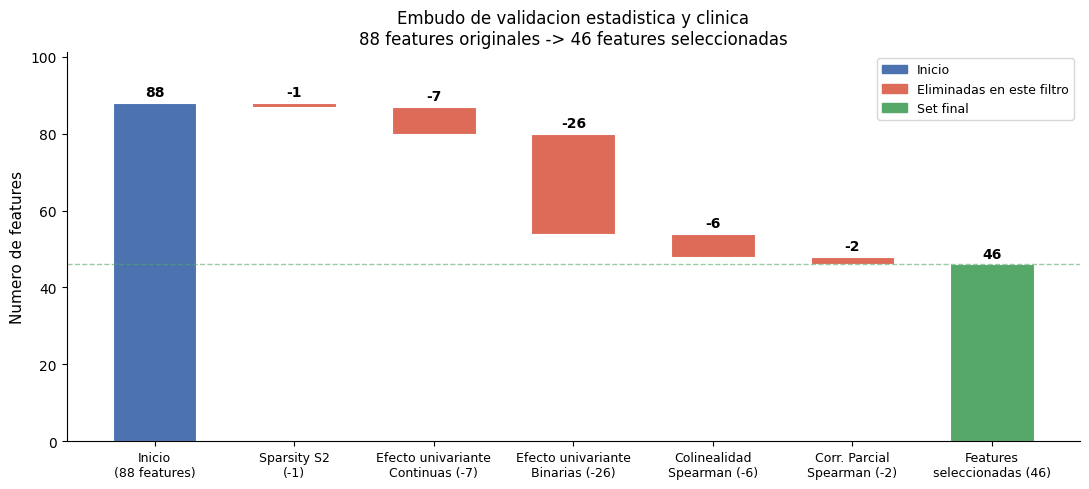

Guardado: waterfall_features.png


In [28]:
import matplotlib.patches as mpatches

# Embudo dinámico: los pasos se derivan de conteos reales del notebook.

n0 = len(TODAS_FEATURES)

# riesgo_complejidad_extrema se crea como nuevo super-flag en S2 (no está en n0),
# pero se descuenta más adelante dentro de bin_s3; compensamos aquí con +1.
n_superflags_nuevos = int(bool(features_superflag) and "riesgo_complejidad_extrema" in df.columns)
n_after_sparsity = n0 - len(features_descartadas_sparsity) - len(features_superflag) + n_superflags_nuevos

n_cont_desc = len(CONTINUAS_DESCARTAR)
n_bin_desc_s3 = len(BINARIAS_DESCARTADAS_S3)
n_spearman = len(BINARIAS_DESCARTADAS_SPEARMAN)
n_parcial = len(BINARIAS_DESCARTADAS_PARCIAL)

n_mid_after_univariate = n_after_sparsity - n_cont_desc - n_bin_desc_s3
n_mid_after_colin = n_mid_after_univariate - n_spearman
n_end = len(FEATURES_SELECCIONADAS)

assert n_end == n_mid_after_colin - n_parcial, (
    "Waterfall inconsistente: "
    f"final={n_end} vs reconstruido={n_mid_after_colin - n_parcial} "
    f"(n0={n0}, after_s2={n_after_sparsity}, cont_desc={n_cont_desc}, bin_s3={n_bin_desc_s3}, "
    f"spearman={n_spearman}, parcial={n_parcial})"
)

fig, ax = plt.subplots(figsize=(11, 5))

pasos = [
    (f"Inicio\n({n0} features)", n0, "start"),
    (f"Sparsity S2\n(-{n0 - n_after_sparsity})", -(n0 - n_after_sparsity), "drop"),
    (f"Efecto univariante\nContinuas (-{n_cont_desc})", -n_cont_desc, "drop"),
    (f"Efecto univariante\nBinarias (-{n_bin_desc_s3})", -n_bin_desc_s3, "drop"),
    (f"Colinealidad\nSpearman (-{n_spearman})", -n_spearman, "drop"),
    (f"Corr. Parcial\nSpearman (-{n_parcial})", -n_parcial, "drop"),
    (f"Features\nseleccionadas ({n_end})", n_end, "end"),
]

COLORES = {"start": "#4C72B0", "drop": "#DD6B58", "end": "#55A868"}

running = 0
bottoms, heights, colors, labels = [], [], [], []

for etiqueta, cambio, tipo in pasos:
    if tipo == "start":
        bottoms.append(0)
        heights.append(cambio)
        running = cambio
    elif tipo == "drop":
        running_new = running + cambio
        bottoms.append(running_new)
        heights.append(-cambio)
        running = running_new
    else:
        bottoms.append(0)
        heights.append(cambio)
    colors.append(COLORES[tipo])
    labels.append(etiqueta)

x = range(len(pasos))
ax.bar(x, heights, bottom=bottoms, color=colors, width=0.6, edgecolor="white", linewidth=0.8)

for i, (b, h, (etiq, cambio, tipo)) in enumerate(zip(bottoms, heights, pasos)):
    valor = cambio if tipo != "end" else n_end
    ypos = b + h + max(1, int(n0 * 0.01))
    ax.text(i, ypos, str(valor), ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Numero de features", fontsize=11)
ax.set_title(
    f"Embudo de validacion estadistica y clinica\n{n0} features originales -> {n_end} features seleccionadas",
    fontsize=12,
)
ax.set_ylim(0, max(n0, 1) * 1.15)
ax.axhline(n_end, color="#55A868", linestyle="--", linewidth=1, alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)

legend_patches = [
    mpatches.Patch(color="#4C72B0", label="Inicio"),
    mpatches.Patch(color="#DD6B58", label="Eliminadas en este filtro"),
    mpatches.Patch(color="#55A868", label="Set final"),
]
ax.legend(handles=legend_patches, loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "waterfall_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: waterfall_features.png")


## 5. Exportación del conjunto validado de características

En esta etapa final se verifican las propiedades estructurales del conjunto depurado y se exportan los datos resultantes. Estos artefactos constituirán la entrada definitiva para el entrenamiento de los modelos predictivos.

In [29]:
# Asserts (version final): binarios sin NaN, continuos con NaN permitido

assert len(FEATURES_SELECCIONADAS) == len(set(FEATURES_SELECCIONADAS)), "Duplicados en FEATURES_SELECCIONADAS"
assert TARGET not in FEATURES_SELECCIONADAS
faltantes = [f for f in FEATURES_SELECCIONADAS if f not in df.columns]
assert not faltantes, f"Faltan columnas en df: {faltantes}"

continuas_final = [f for f in FEATURES_SELECCIONADAS if f in CONTINUAS_POST_S3]
binarias_final  = [f for f in FEATURES_SELECCIONADAS if f not in CONTINUAS_POST_S3]

binarias_con_nan = [c for c in binarias_final if df[c].isna().any()]
assert not binarias_con_nan, f"Binarias con NaN (inesperado): {binarias_con_nan}"

print("Asserts OK")
print(f"  Features seleccionadas: {len(FEATURES_SELECCIONADAS)}")
print(f"  Continuas            : {len(continuas_final)}")
print(f"  Binarias             : {len(binarias_final)}")

reporte_nan = df[continuas_final].isna().sum().rename("n_nan").to_frame()
reporte_nan["pct_nan"] = (reporte_nan["n_nan"] / len(df) * 100).round(2)
reporte_nan = reporte_nan.query("n_nan > 0").sort_values("pct_nan", ascending=False)

if len(reporte_nan) > 0:
    print("\nNaN en continuas (esperado):")
    print(reporte_nan.to_string())
else:
    print("\nNaN en continuas: 0")

# Guardar decisiones finales en JSON
for f in TODAS_FEATURES:
    if f in FEATURES_SELECCIONADAS:
        update_metrics_json(f, decision_final='seleccionada')
    else:
        update_metrics_json(f, decision_final='descartada')
if 'riesgo_complejidad_extrema' in df.columns:
    if 'riesgo_complejidad_extrema' in FEATURES_SELECCIONADAS:
        update_metrics_json('riesgo_complejidad_extrema', decision_final='seleccionada')
    else:
        update_metrics_json('riesgo_complejidad_extrema', decision_final='descartada')
print('Decisiones guardadas en feature_metrics.json')


Asserts OK
  Features seleccionadas: 46
  Continuas            : 9
  Binarias             : 37

NaN en continuas (esperado):
          n_nan  pct_nan
pain      32505   7.7700
o2sat     13930   3.3300
resprate  13603   3.2500
sbp       11686   2.8000
age          75   0.0200
Decisiones guardadas en feature_metrics.json


In [30]:
# --- Export ---

# Dataset purgado
df[FEATURES_SELECCIONADAS + [TARGET]].to_parquet(
    PROCESSED_DIR / "dataset_features_selected.parquet",
    index=False,
)

# Feature config
feature_config_selected = {
    "features_seleccionadas": FEATURES_SELECCIONADAS,
    "target": TARGET,
    "n_features_original": len(TODAS_FEATURES),
    "n_features_seleccionadas": len(FEATURES_SELECCIONADAS),
    "n_features_eliminadas": len(TODAS_FEATURES) - len(FEATURES_SELECCIONADAS),
    "criterios": {
        "sparsity_umbral_pct":           1.0,
        "eta2_umbral_descartar":         0.01,
        "cramer_v_umbral_descartar":     0.07,
        "spearman_auto_descartar":       0.85,
        "spearman_revision_manual":      0.70,
    },
    "overrides_clinicos": [
        "cc_alergia_anafilaxia: distribucion concentrada en acuity 1-2; regla de nicho explotable por arbol",
    ],
}

with open(PROCESSED_DIR / "feature_config_selected.json", "w", encoding="utf-8") as f:
    json.dump(feature_config_selected, f, indent=2, ensure_ascii=False)

shape = df[FEATURES_SELECCIONADAS + [TARGET]].shape
print(f"Exportado: dataset_features_selected.parquet  {shape}")
print(f"Exportado: feature_config_selected.json       ({len(FEATURES_SELECCIONADAS)} features)")
print()
print(f"Pipeline de validacion completado.")
print(f"  {len(TODAS_FEATURES)} features originales -> {len(FEATURES_SELECCIONADAS)} features seleccionadas")
print(f"  Reduccion: {len(TODAS_FEATURES) - len(FEATURES_SELECCIONADAS)} features eliminadas ({(len(TODAS_FEATURES) - len(FEATURES_SELECCIONADAS)) / len(TODAS_FEATURES) * 100:.0f}%)")

Exportado: dataset_features_selected.parquet  (418100, 47)
Exportado: feature_config_selected.json       (46 features)

Pipeline de validacion completado.
  88 features originales -> 46 features seleccionadas
  Reduccion: 42 features eliminadas (48%)


## 6. Resumen visual del proceso de validación

### Gráfico 1: Reducción del espacio de características

Visualización del embudo de selección (waterfall), ilustrando la trayectoria desde las variables iniciales hasta las 46 características retenidas (sin contar el target `acuity`), cuantificando la reducción aportada en cada filtro metodológico.

### Gráfico 2: Capacidad predictiva univariante

Comparativa del poder predictivo de las características seleccionadas. A la izquierda se muestran las variables continuas ordenadas por su tamaño de efecto ($\eta^2$). A la derecha se detallan las principales variables binarias jerarquizadas por su valor de $V$ de Cramér, ambas coloreadas según su dominio clínico.

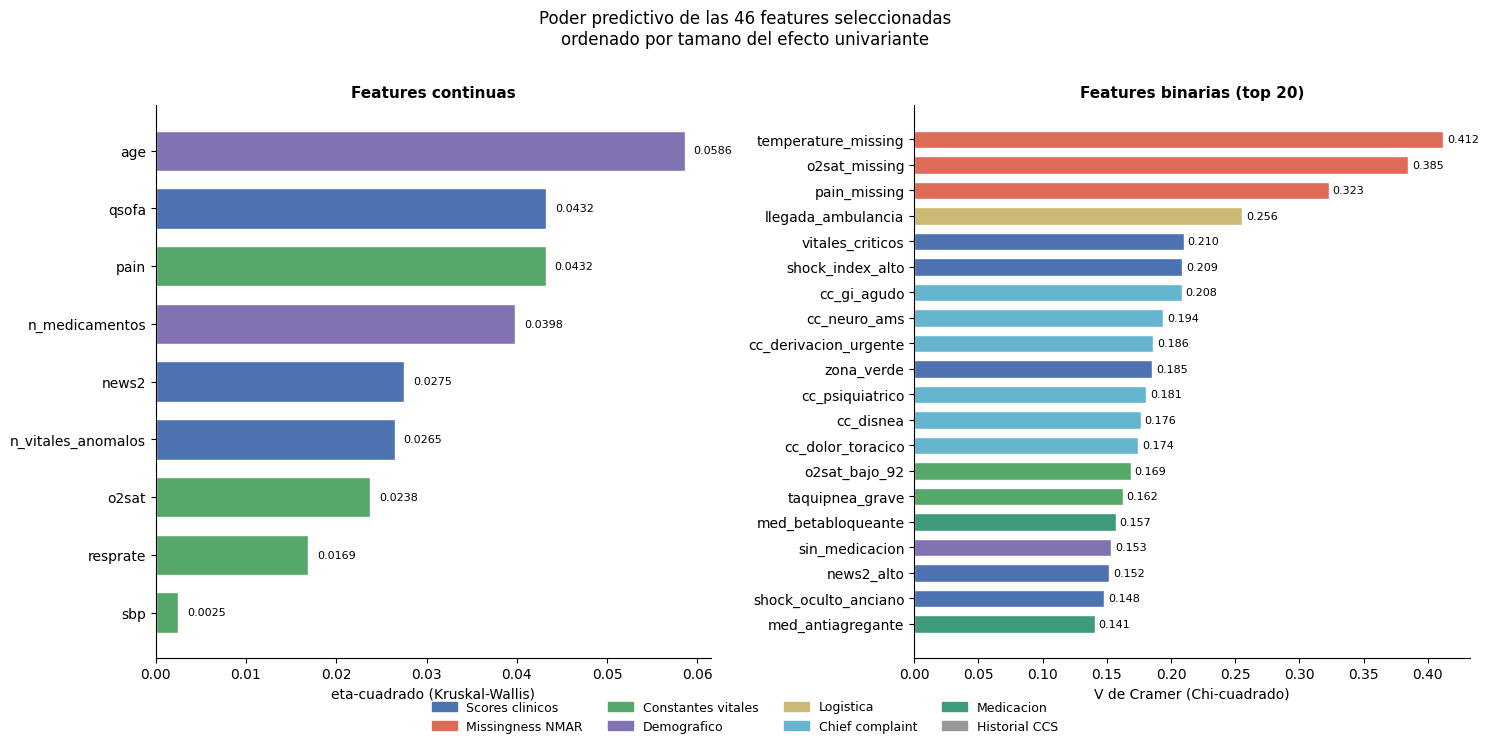

Guardado: ranking_poder.png


In [31]:
DOMAIN_MAP = {
    "qsofa": "Scores clinicos",        "news2": "Scores clinicos",
    "n_vitales_anomalos": "Scores clinicos",
    "qsofa_positivo": "Scores clinicos", "news2_alto": "Scores clinicos",
    "vitales_criticos": "Scores clinicos", "shock_index_alto": "Scores clinicos",
    "shock_oculto_anciano": "Scores clinicos", "sirs_positivo": "Scores clinicos",
    "zona_verde": "Scores clinicos",
    "temperature_missing": "Missingness NMAR", "o2sat_missing": "Missingness NMAR",
    "pain_missing": "Missingness NMAR",
    "pain": "Constantes vitales",  "o2sat": "Constantes vitales",
    "resprate": "Constantes vitales", "sbp": "Constantes vitales",
    "o2sat_bajo_92": "Constantes vitales", "taquipnea_grave": "Constantes vitales",
    "age": "Demografico",           "n_medicamentos": "Demografico",
    "sin_medicacion": "Demografico", "identidad_desconocida": "Demografico",
    "llegada_ambulancia": "Logistica", "llegada_helicoptero": "Logistica",
    "llegada_desconocida": "Logistica",
    "cc_dolor_toracico": "Chief complaint", "cc_disnea": "Chief complaint",
    "cc_gi_agudo": "Chief complaint",      "cc_neuro_ams": "Chief complaint",
    "cc_trauma": "Chief complaint",        "cc_psiquiatrico": "Chief complaint",
    "cc_urologico": "Chief complaint",     "cc_alergia_anafilaxia": "Chief complaint",
    "cc_derivacion_urgente": "Chief complaint",
    "med_antiagregante": "Medicacion",  "med_insulina": "Medicacion",
    "med_opiaceo": "Medicacion",        "med_betabloqueante": "Medicacion",
    "med_ace_ara2": "Medicacion",       "med_diuretico_asa": "Medicacion",
    "med_antipsicótico": "Medicacion",  "med_ssri_snri": "Medicacion",
    "med_anticonvulsivante": "Medicacion",
    "alto_riesgo_sangrado": "Medicacion", "alto_riesgo_delirium": "Medicacion",
    "hx_cardiaco": "Historial CCS",
}

PALETTE = {
    "Scores clinicos":   "#4C72B0",
    "Missingness NMAR":  "#DD6B58",
    "Constantes vitales":"#55A868",
    "Demografico":       "#8172B2",
    "Logistica":         "#CCB974",
    "Chief complaint":   "#64B5CD",
    "Medicacion":        "#3E9B7A",
    "Historial CCS":     "#999999",
}

# Datos filtrados al set seleccionado
with open(METRICS_FILE, 'r', encoding='utf-8') as f:
    metrics = json.load(f)['features_con_metricas']

kw_sel_list = []
chi2_sel_list = []
for feat in FEATURES_SELECCIONADAS:
    m = metrics.get(feat, {})
    if m.get('eta2') is not None:
        kw_sel_list.append({'feature': feat, 'eta2': m['eta2']})
    if m.get('V_cramer') is not None:
        chi2_sel_list.append({'feature': feat, 'V_cramer': m['V_cramer']})

kw_sel = pd.DataFrame(kw_sel_list).sort_values('eta2')
chi2_sel = pd.DataFrame(chi2_sel_list).sort_values('V_cramer', ascending=False).head(20).sort_values('V_cramer')
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(15, 7))

# Subplot izquierdo: continuas por eta2
colors_l = [PALETTE.get(DOMAIN_MAP.get(f, ""), "#aaaaaa") for f in kw_sel["feature"]]
ax_l.barh(kw_sel["feature"], kw_sel["eta2"], color=colors_l, edgecolor="white", height=0.7)
ax_l.set_xlabel("eta-cuadrado (Kruskal-Wallis)", fontsize=10)
ax_l.set_title("Features continuas", fontsize=11, fontweight="bold")
ax_l.spines[["top", "right"]].set_visible(False)
for v, f in zip(kw_sel["eta2"], kw_sel["feature"]):
    ax_l.text(v + 0.001, f, f"{v:.4f}", va="center", fontsize=8)

# Subplot derecho: binarias por V de Cramer (top 20)
colors_r = [PALETTE.get(DOMAIN_MAP.get(f, ""), "#aaaaaa") for f in chi2_sel["feature"]]
ax_r.barh(chi2_sel["feature"], chi2_sel["V_cramer"], color=colors_r, edgecolor="white", height=0.7)
ax_r.set_xlabel("V de Cramer (Chi-cuadrado)", fontsize=10)
ax_r.set_title("Features binarias (top 20)", fontsize=11, fontweight="bold")
ax_r.spines[["top", "right"]].set_visible(False)
for v, f in zip(chi2_sel["V_cramer"], chi2_sel["feature"]):
    ax_r.text(v + 0.003, f, f"{v:.3f}", va="center", fontsize=8)

# Leyenda compartida
handles = [mpatches.Patch(color=c, label=d) for d, c in PALETTE.items()]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.04), frameon=False)

fig.suptitle(f"Poder predictivo de las {len(FEATURES_SELECCIONADAS)} features seleccionadas\nordenado por tamano del efecto univariante",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "ranking_poder.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: ranking_poder.png")

### Gráfico 3: Distribución del efecto frente a prevalencia

Análisis de dispersión de las características binarias seleccionadas. El gráfico relaciona la prevalencia poblacional (eje horizontal) con la magnitud del efecto medido por $V$ de Cramér (eje vertical). Las zonas sombreadas delimitan visualmente los criterios de descarte automático por escasez de datos o efecto débil.

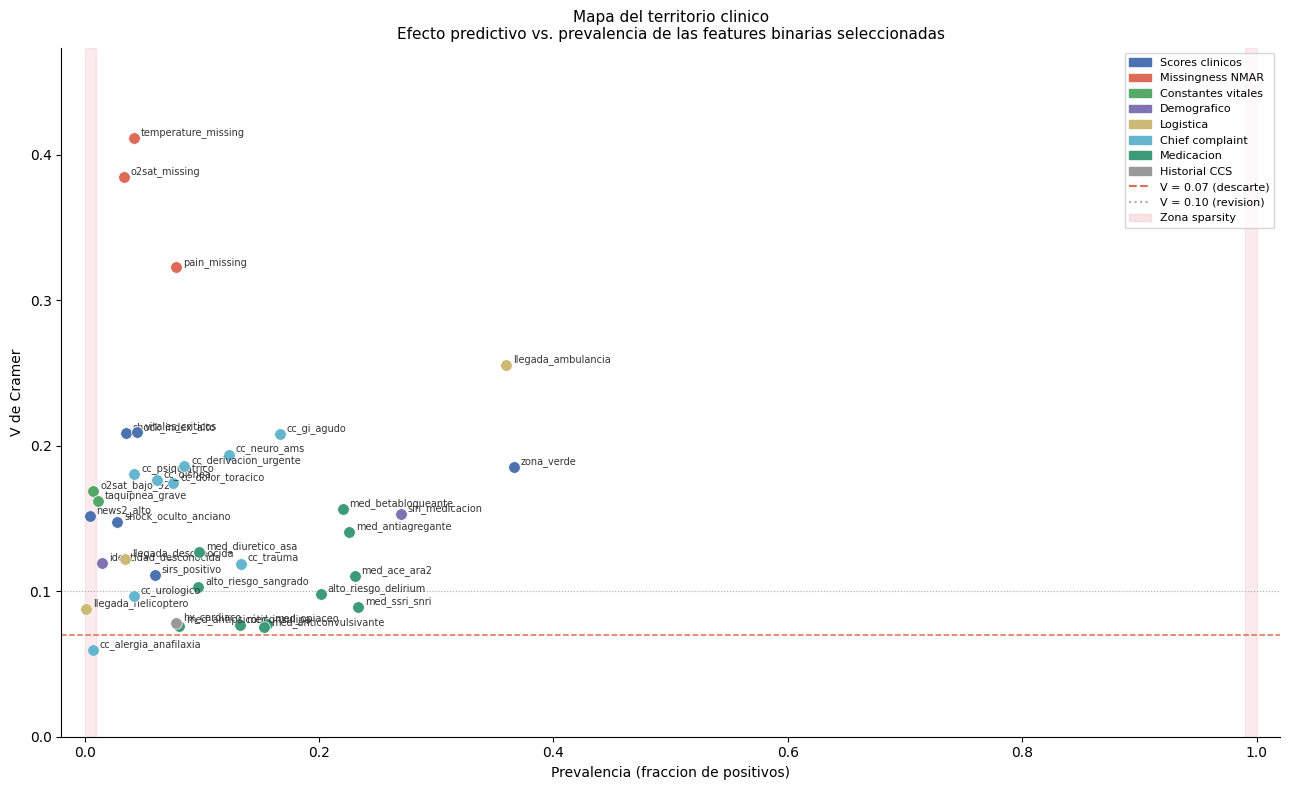

Guardado: mapa_territorio.png


In [32]:
with open(METRICS_FILE, 'r', encoding='utf-8') as f:
    metrics = json.load(f)['features_con_metricas']

scatter_list = []
for feat in FEATURES_SELECCIONADAS:
    m = metrics.get(feat, {})
    if m.get('V_cramer') is not None:
        scatter_list.append({
            'feature': feat, 
            'V_cramer': m['V_cramer'],
            'prevalencia': df[feat].mean(),
            'dominio': DOMAIN_MAP.get(feat, 'Otro')
        })
scatter_df = pd.DataFrame(scatter_list)
fig, ax = plt.subplots(figsize=(13, 8))

# Zona de sparsity (prevalencia < 1% o > 99%)
ax.axvspan(0, 0.01, color="#f5c6cb", alpha=0.35, label="Zona sparsity (< 1 %)")
ax.axvspan(0.99, 1.0, color="#f5c6cb", alpha=0.35)

# Umbral de efecto debil
ax.axhline(0.07, color="#DD6B58", linewidth=1.1, linestyle="--", label="Umbral V = 0.07 (descarte)")
ax.axhline(0.10, color="#aaaaaa", linewidth=0.8, linestyle=":", label="Umbral V = 0.10 (revision)")

for _, row in scatter_df.iterrows():
    color = PALETTE.get(row["dominio"], "#aaaaaa")
    ax.scatter(row["prevalencia"], row["V_cramer"], color=color, s=70, zorder=3, edgecolors="white", linewidth=0.5)
    ax.annotate(
        row["feature"],
        xy=(row["prevalencia"], row["V_cramer"]),
        xytext=(5, 2),
        textcoords="offset points",
        fontsize=7,
        color="#333333",
    )

# Leyenda de dominios
dom_handles = [mpatches.Patch(color=c, label=d) for d, c in PALETTE.items() if d != "Otro"]
dom_handles += [
    plt.Line2D([0], [0], color="#DD6B58", linestyle="--", label="V = 0.07 (descarte)"),
    plt.Line2D([0], [0], color="#aaaaaa", linestyle=":", label="V = 0.10 (revision)"),
    mpatches.Patch(color="#f5c6cb", alpha=0.5, label="Zona sparsity"),
]
ax.legend(handles=dom_handles, loc="upper right", fontsize=8, frameon=True)

ax.set_xlabel("Prevalencia (fraccion de positivos)", fontsize=10)
ax.set_ylabel("V de Cramer", fontsize=10)
ax.set_title(
    "Mapa del territorio clinico\nEfecto predictivo vs. prevalencia de las features binarias seleccionadas",
    fontsize=11
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, scatter_df["V_cramer"].max() * 1.15)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "mapa_territorio.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: mapa_territorio.png")

### Gráfico 4: Matriz de correlaciones del conjunto final

Mapa de calor que representa las correlaciones de Spearman entre las 47 características finales, agrupadas temáticamente por dominio clínico. Esto permite verificar visualmente la ausencia de redundancias significativas ($|
ho| > 0.85$) y confirmar la independencia estadística general del conjunto de variables que se suministrará al modelo.

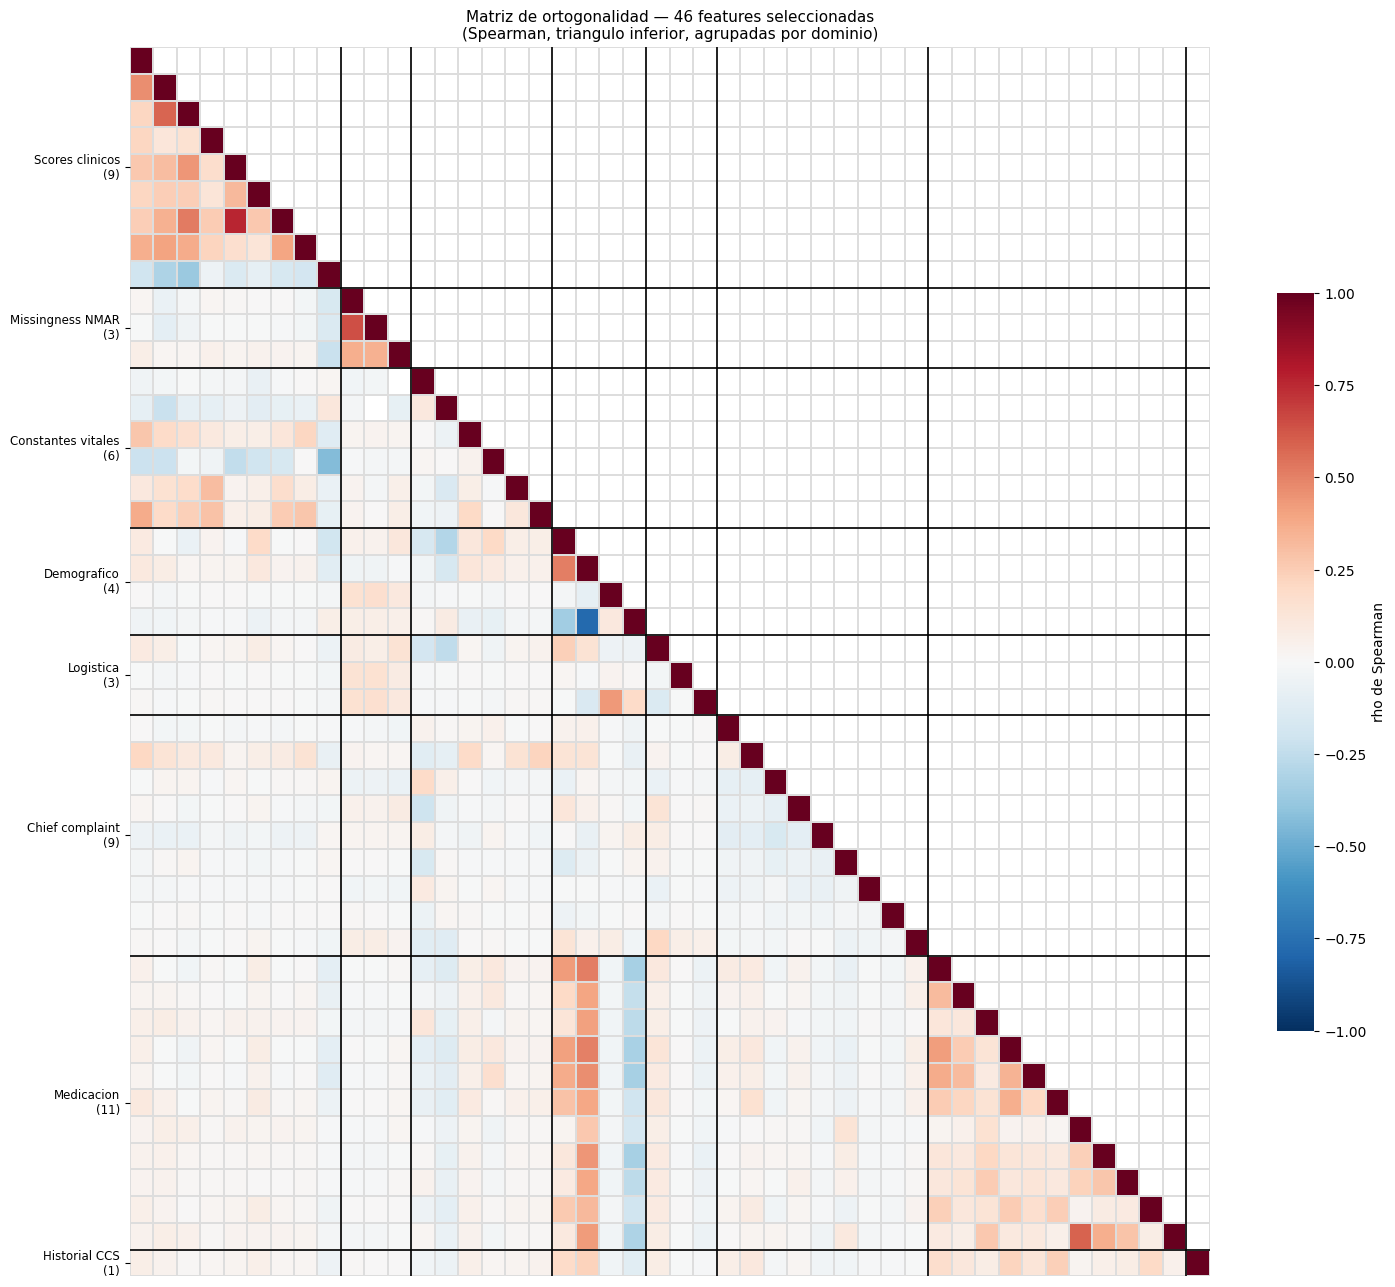

Guardado: heatmap_ortogonalidad.png

Par de mayor correlacion residual: n_medicamentos <-> sin_medicacion  rho = -0.777


In [33]:
import seaborn as sns

# Orden por dominio para que los bloques queden agrupados
DOMAIN_ORDER = [
    "Scores clinicos", "Missingness NMAR", "Constantes vitales",
    "Demografico", "Logistica", "Chief complaint", "Medicacion", "Historial CCS",
]

def domain_key(f):
    d = DOMAIN_MAP.get(f, "Otro")
    return DOMAIN_ORDER.index(d) if d in DOMAIN_ORDER else len(DOMAIN_ORDER)

ordered_features = sorted(FEATURES_SELECCIONADAS, key=domain_key)

# Correlacion de Spearman sobre el set final
df_sel = df[ordered_features].copy()
corr_matrix = df_sel.rank(method="average").corr(method="pearson")  # equivalente a Spearman

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(15, 13))

sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor="#dddddd",
    annot=False,
    cbar_kws={"shrink": 0.6, "label": "rho de Spearman"},
)

# Lineas separadoras por dominio
domain_groups = {}
for f in ordered_features:
    d = DOMAIN_MAP.get(f, "Otro")
    domain_groups.setdefault(d, []).append(f)

boundary = 0
for dom in DOMAIN_ORDER:
    grp = domain_groups.get(dom, [])
    if not grp:
        continue
    boundary += len(grp)
    if boundary < len(ordered_features):
        ax.axhline(boundary, color="black", linewidth=1.2)
        ax.axvline(boundary, color="black", linewidth=1.2)

# Etiquetas de dominio en el eje Y
ytick_positions = []
ytick_labels = []
pos = 0
for dom in DOMAIN_ORDER:
    grp = domain_groups.get(dom, [])
    if not grp:
        continue
    mid = pos + len(grp) / 2
    ytick_positions.append(mid)
    ytick_labels.append(f"{dom}\n({len(grp)})")
    pos += len(grp)

ax.set_yticks(ytick_positions)
ax.set_yticklabels(ytick_labels, fontsize=8.5)
ax.set_xticks([])
ax.set_xlabel("")
ax.set_title(
    f"Matriz de ortogonalidad — {len(FEATURES_SELECCIONADAS)} features seleccionadas\n(Spearman, triangulo inferior, agrupadas por dominio)",
    fontsize=11
)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "heatmap_ortogonalidad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: heatmap_ortogonalidad.png")

# Verificacion: par de mayor correlacion residual
corr_vals = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool)).stack()
max_pair = corr_vals.abs().idxmax()
print(f"\nPar de mayor correlacion residual: {max_pair[0]} <-> {max_pair[1]}  rho = {corr_vals[max_pair]:.3f}")

## 7. Split temporal y exportación de artefactos de entrenamiento

Con el conjunto de features validadas, se procede a la partición temporal del dataset y la generación de los artefactos definitivos de entrenamiento.

El split utiliza la columna `intime` (fecha de ingreso) del dataset original para garantizar que la evaluación simula un escenario de despliegue real, donde el modelo solo se entrena con datos anteriores a la fecha de corte.

**Configuración del split:**
- **Criterio temporal:** percentil 80 de `intime` (80% train / 20% test)
- **Sample weights:** método `balanced` para compensar el desbalanceo de clases (`acuity`)
- **Groups:** `subject_id` para uso con `GroupKFold` durante el modelado, evitando fuga de información entre pacientes

In [37]:
# -- Carga de datos temporales del dataset original --
from triaje_ia.data.cleaner import cargar_dataset_limpio
from sklearn.utils.class_weight import compute_sample_weight

df_original = cargar_dataset_limpio(forzar=False)

# Verificacion de alineacion entre datasets
assert len(df_original) == len(df), (
    f"Desalineacion: df_original={len(df_original)}, df={len(df)}"
)

# -- Split temporal (80/20) --
fecha_corte = df_original["intime"].quantile(0.80)
print(f"Fecha de corte (percentil 80): {fecha_corte}")
print(f"Rango train: {df_original['intime'].min()} -> {fecha_corte}")
print(f"Rango test:  {fecha_corte} -> {df_original['intime'].max()}")

mask_train = df_original["intime"] <= fecha_corte
mask_test  = df_original["intime"] >  fecha_corte

print(f"\nTrain: {mask_train.sum():,} filas ({mask_train.mean()*100:.1f}%)")
print(f"Test:  {mask_test.sum():,} filas ({mask_test.mean()*100:.1f}%)")

# -- Verificar distribucion del target --
print("\nDistribucion acuity train:")
print(df[mask_train][TARGET].value_counts(normalize=True).sort_index().round(3).to_string())
print("\nDistribucion acuity test:")
print(df[mask_test][TARGET].value_counts(normalize=True).sort_index().round(3).to_string())

# -- Split con features seleccionadas (47) --
X_train = df[mask_train][FEATURES_SELECCIONADAS].copy()
y_train = df[mask_train][TARGET].copy()
X_test  = df[mask_test][FEATURES_SELECCIONADAS].copy()
y_test  = df[mask_test][TARGET].copy()

# Groups para GroupKFold (subject_id del dataset original)
groups_train = df_original[mask_train]["subject_id"].values

print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

# -- Sample weights (solo sobre train) --
sw_balanced = compute_sample_weight(                        # base teórica: inversamente proporcional a freq de clase
    class_weight="balanced", y=y_train
)
sample_weights_train = np.sqrt(sw_balanced)                 # suavizado sqrt: reduce clase 5 de 192x a ~14x vs clase 3, evitando precision≈0 en clase 5
sample_weights_train = (                                    # renormalización: la suma de pesos debe ser igual al nº de muestras para que lr y regularización no se vean afectados
    sample_weights_train / sample_weights_train.mean()
)

print(f"\nSample weights (sqrt-balanced):")
for acuity in sorted(y_train.unique()):
    w = sample_weights_train[y_train.values == acuity].mean()
    print(f"  acuity {acuity}: peso medio = {w:.4f}")       

# -- Exportacion de artefactos de entrenamiento --
X_train.to_parquet(PROCESSED_DIR / "X_train.parquet", index=False)
X_test.to_parquet(PROCESSED_DIR / "X_test.parquet", index=False)
y_train.to_frame().to_parquet(PROCESSED_DIR / "y_train.parquet", index=False)
y_test.to_frame().to_parquet(PROCESSED_DIR / "y_test.parquet", index=False)

np.save(PROCESSED_DIR / "groups_train.npy", groups_train)
np.save(PROCESSED_DIR / "sample_weights_train.npy", sample_weights_train)

print(f"\n-- Archivos exportados --")
for archivo in sorted(PROCESSED_DIR.iterdir()):
    size_mb = archivo.stat().st_size / 1024**2
    print(f"  {archivo.name:<35} {size_mb:.1f} MB")

2026-05-09 19:25:34.141 | WARNING  | triaje_ia.data.cleaner:cargar_dataset_limpio:193 - Cargando desde caché: C:\Users\CARLOS\triaje-ia-tfg\data\interim\dataset_clean.parquet. Si cambiaste el pipeline, usa forzar=True.
2026-05-09 19:25:34.762 | SUCCESS  | triaje_ia.data.cleaner:cargar_dataset_limpio:198 - Cargado: 418,100 filas | 21 columnas


Fecha de corte (percentil 80): 2180-06-06 02:38:36
Rango train: 2110-01-11 01:45:00 -> 2180-06-06 02:38:36
Rango test:  2180-06-06 02:38:36 -> 2212-04-05 23:23:00

Train: 334,480 filas (80.0%)
Test:  83,620 filas (20.0%)

Distribucion acuity train:
acuity
1   0.0580
2   0.3330
3   0.5370
4   0.0690
5   0.0030

Distribucion acuity test:
acuity
1   0.0560
2   0.3370
3   0.5430
4   0.0630
5   0.0020

X_train: (334480, 46)
X_test:  (83620, 46)

Sample weights (sqrt-balanced):
  acuity 1: peso medio = 2.2260
  acuity 2: peso medio = 0.9288
  acuity 3: peso medio = 0.7309
  acuity 4: peso medio = 2.0323
  acuity 5: peso medio = 10.1485

-- Archivos exportados --
  dataset_features.parquet            7.0 MB
  dataset_features_selected.parquet   3.6 MB
  feature_config.json                 0.0 MB
  feature_config_selected.json        0.0 MB
  groups_train.npy                    2.6 MB
  mejores_parametros_rf.json          0.0 MB
  sample_weights_train.npy            2.6 MB
  X_test.parquet    

In [38]:
# -- Resumen final del pipeline completo --
print("=" * 65)
print("  PIPELINE COMPLETO: Feature Engineering + Validacion")
print("=" * 65)
print(f"\n  Features originales (05):     {len(TODAS_FEATURES)}")
print(f"  Features seleccionadas (05b): {len(FEATURES_SELECCIONADAS)}")
print(f"  Reduccion:                    "
      f"{len(TODAS_FEATURES) - len(FEATURES_SELECCIONADAS)} features eliminadas "
      f"({(len(TODAS_FEATURES) - len(FEATURES_SELECCIONADAS))/len(TODAS_FEATURES)*100:.0f}%)")
print(f"\n  Split temporal (80/20):")
print(f"    Train: {X_train.shape[0]:,} filas x {X_train.shape[1]} features")
print(f"    Test:  {X_test.shape[0]:,} filas x {X_test.shape[1]} features")
print(f"\n  Artefactos exportados en data/processed/:")
print(f"    X_train.parquet, X_test.parquet")
print(f"    y_train.parquet, y_test.parquet")
print(f"    groups_train.npy, sample_weights_train.npy")
print(f"    feature_config_selected.json")
print(f"    dataset_features_selected.parquet")
print(f"\n  Siguiente paso: notebooks de modelado")
print("=" * 65)

  PIPELINE COMPLETO: Feature Engineering + Validacion

  Features originales (05):     88
  Features seleccionadas (05b): 46
  Reduccion:                    42 features eliminadas (48%)

  Split temporal (80/20):
    Train: 334,480 filas x 46 features
    Test:  83,620 filas x 46 features

  Artefactos exportados en data/processed/:
    X_train.parquet, X_test.parquet
    y_train.parquet, y_test.parquet
    groups_train.npy, sample_weights_train.npy
    feature_config_selected.json
    dataset_features_selected.parquet

  Siguiente paso: notebooks de modelado
